# LAB-7: Batch Gradient Descent, SGD, and Mini-Batch Gradient Descent using TensorFlow

**Aim:** To implement Batch Gradient Descent (BGD), Stochastic Gradient Descent (SGD), and Mini-Batch Gradient Descent (MBGD) using TensorFlow on a simple regression problem and compare their convergence behavior.

## Dataset Preparation

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

X = np.random.rand(1000, 1).astype(np.float32)
y = (3 * X + 2 + np.random.randn(1000, 1) * 0.1).astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

2026-03-09 13:59:19.691489: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 13:59:19.739596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 13:59:32.203796: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


X shape: (1000, 1)
y shape: (1000, 1)


## Model Definition

In [ ]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, input_shape=(1,))
    ])
    return model

loss_fn = tf.keras.losses.MeanSquaredError()
epochs = 50

## Experiment 1: Batch Gradient Descent

Uses the entire dataset to compute gradients each update. Stable but slow for large datasets.

In [ ]:
model_bgd = build_model()
optimizer_bgd = tf.keras.optimizers.SGD(learning_rate=0.01)
bgd_losses = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        preds = model_bgd(X, training=True)
        loss = loss_fn(y, preds)
    grads = tape.gradient(loss, model_bgd.trainable_variables)
    optimizer_bgd.apply_gradients(zip(grads, model_bgd.trainable_variables))
    bgd_losses.append(loss.numpy())

print("BGD Final Loss:", bgd_losses[-1])
w, b = model_bgd.layers[0].get_weights()
print(f"Learned: y = {w[0][0]:.4f}x + {b[0]:.4f}")

/workspaces/SEM-VI/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-09 12:59:58.227427: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


BGD Final Loss: 0.6111066
Learned: y = 2.4773x + 1.5247


## Experiment 2: Stochastic Gradient Descent (SGD)

Uses one sample at a time. Faster updates per epoch but noisy convergence.

In [ ]:
model_sgd = build_model()
optimizer_sgd = tf.keras.optimizers.SGD(learning_rate=0.01)
sgd_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X))
    epoch_loss = 0.0
    for i in indices:
        xi = X[i:i+1]
        yi = y[i:i+1]
        with tf.GradientTape() as tape:
            pred = model_sgd(xi, training=True)
            loss = loss_fn(yi, pred)
        grads = tape.gradient(loss, model_sgd.trainable_variables)
        optimizer_sgd.apply_gradients(zip(grads, model_sgd.trainable_variables))
        epoch_loss += loss.numpy()
    sgd_losses.append(epoch_loss / len(X))

print("SGD Final Loss:", sgd_losses[-1])
w, b = model_sgd.layers[0].get_weights()
print(f"Learned: y = {w[0][0]:.4f}x + {b[0]:.4f}")

SGD Final Loss: 0.009855974
Learned: y = 2.9795x + 2.0044


## Experiment 3: Mini-Batch Gradient Descent

Uses small batches of data. Provides a balance between BGD stability and SGD speed.

In [ ]:
model_mbgd = build_model()
optimizer_mbgd = tf.keras.optimizers.SGD(learning_rate=0.01)
batch_size = 32
mbgd_losses = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    epoch_loss = 0.0
    num_batches = len(X) // batch_size
    for i in range(num_batches):
        xb = X_shuffled[i*batch_size:(i+1)*batch_size]
        yb = y_shuffled[i*batch_size:(i+1)*batch_size]
        with tf.GradientTape() as tape:
            preds = model_mbgd(xb, training=True)
            loss = loss_fn(yb, preds)
        grads = tape.gradient(loss, model_mbgd.trainable_variables)
        optimizer_mbgd.apply_gradients(zip(grads, model_mbgd.trainable_variables))
        epoch_loss += loss.numpy()
    mbgd_losses.append(epoch_loss / num_batches)

print("MBGD Final Loss:", mbgd_losses[-1])
w, b = model_mbgd.layers[0].get_weights()
print(f"Learned: y = {w[0][0]:.4f}x + {b[0]:.4f}")

MBGD Final Loss: 0.013631453
Learned: y = 2.7783x + 2.1262


## Comparative Chart: BGD vs SGD vs Mini-Batch GD

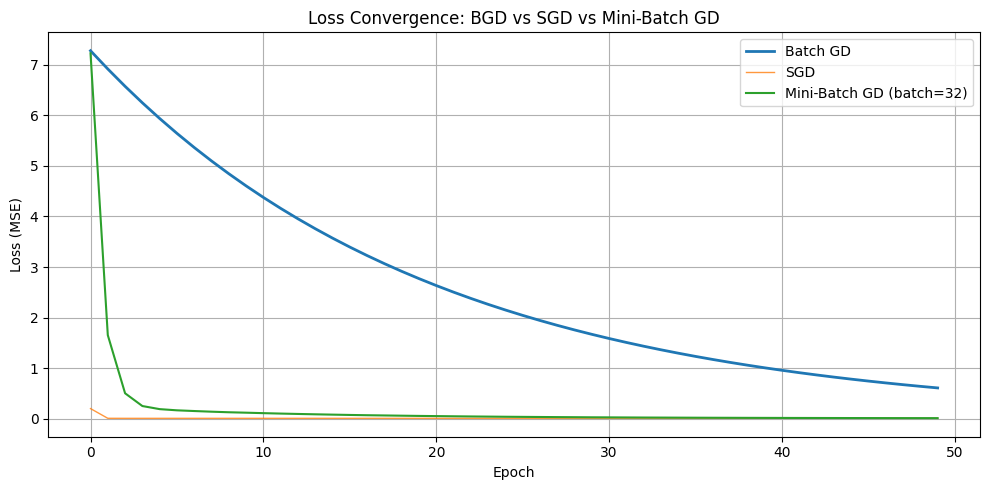

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(bgd_losses, label='Batch GD', linewidth=2)
plt.plot(sgd_losses, label='SGD', linewidth=1, alpha=0.8)
plt.plot(mbgd_losses, label='Mini-Batch GD (batch=32)', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Convergence: BGD vs SGD vs Mini-Batch GD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Knowledge Check

**1. Why does Batch Gradient Descent have a smooth loss curve but slow convergence?**
BGD computes the gradient using the full dataset, so each update is accurate and noise-free, producing a smooth curve. However, each update requires a full pass through all data, making it slow per iteration.

**2. What causes fluctuations in the loss function when using SGD?**
SGD updates weights using just one sample at a time. Each sample has its own noise, so the gradient direction varies from step to step, causing the loss to fluctuate.

**3. Why is Mini-Batch Gradient Descent preferred for training deep neural networks?**
Mini-batch GD balances computation efficiency and gradient accuracy. It is faster than BGD, less noisy than SGD, and hardware (GPU/CPU) is optimized for batch matrix operations.

**4. What happens if the batch size is increased to the full dataset?**
It becomes equivalent to Batch Gradient Descent — smooth and stable updates but high memory usage and slow convergence.

**5. How does shuffling the dataset affect SGD and Mini-Batch GD?**
Shuffling prevents the model from learning any ordering pattern in the data and ensures each epoch exposes the model to varied samples, improving generalization and avoiding cyclical bias in updates.

## Exercise 1: Effect of Learning Rate

Train the model using Mini-Batch GD with learning rates 0.001, 0.01, and 0.1.

LR=0.001 | Final Loss: 0.407199
LR=0.01 | Final Loss: 0.010039
LR=0.1 | Final Loss: 0.009743


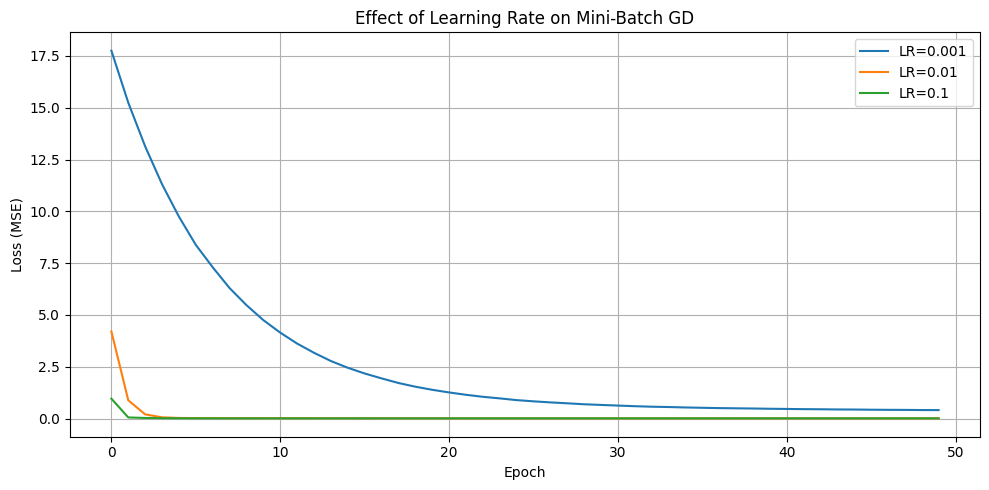

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
lr_losses = {}

for lr in learning_rates:
    model = build_model()
    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)
    losses = []
    for epoch in range(epochs):
        indices = np.random.permutation(len(X))
        X_s = X[indices]
        y_s = y[indices]
        epoch_loss = 0.0
        num_batches = len(X) // batch_size
        for i in range(num_batches):
            xb = X_s[i*batch_size:(i+1)*batch_size]
            yb = y_s[i*batch_size:(i+1)*batch_size]
            with tf.GradientTape() as tape:
                preds = model(xb, training=True)
                loss = loss_fn(yb, preds)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            epoch_loss += loss.numpy()
        losses.append(epoch_loss / num_batches)
    lr_losses[lr] = losses
    print(f"LR={lr} | Final Loss: {losses[-1]:.6f}")

plt.figure(figsize=(10, 5))
for lr, losses in lr_losses.items():
    plt.plot(losses, label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Effect of Learning Rate on Mini-Batch GD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Exercise 1 Answers:**

**1. Which learning rate converges fastest?**

LR = 0.1 converges fastest.

**2. Which learning rate causes instability?**

LR = 0.1 can cause instability or oscillation if it overshoots the minimum.

**3. What happens if the learning rate is too small?**

The model learns very slowly and may not converge within the given epochs (e.g., LR = 0.001).

## Exercise 2: Effect of Batch Size

Train the model using batch sizes: 1, 16, 64, and the full dataset.

Batch=1 | Final Loss: 0.009895
Batch=16 | Final Loss: 0.009851
Batch=64 | Final Loss: 0.019340
Full Dataset | Final Loss: 1.769705


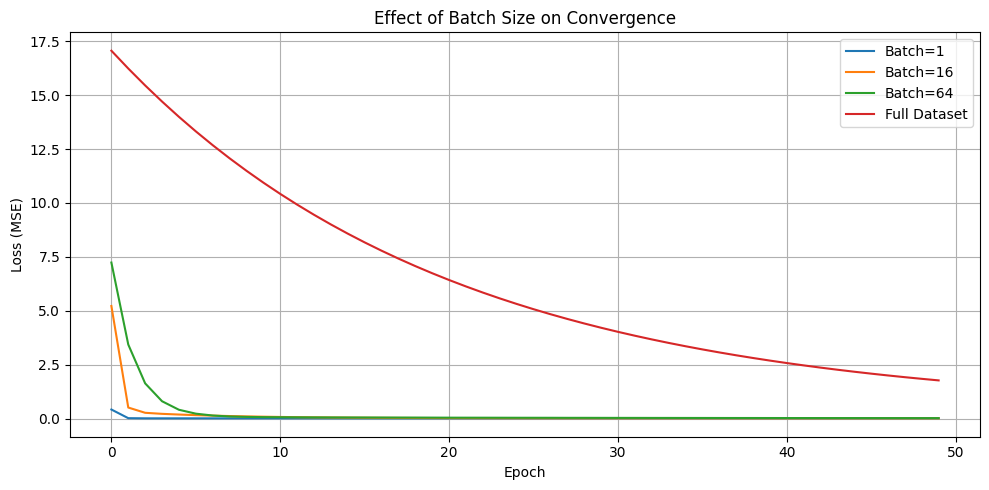

In [ ]:
batch_sizes = [1, 16, 64, len(X)]
bs_losses = {}

for bs in batch_sizes:
    model = build_model()
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    losses = []
    for epoch in range(epochs):
        indices = np.random.permutation(len(X))
        X_s = X[indices]
        y_s = y[indices]
        epoch_loss = 0.0
        num_batches = len(X) // bs
        for i in range(num_batches):
            xb = X_s[i*bs:(i+1)*bs]
            yb = y_s[i*bs:(i+1)*bs]
            with tf.GradientTape() as tape:
                preds = model(xb, training=True)
                loss = loss_fn(yb, preds)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            epoch_loss += loss.numpy()
        losses.append(epoch_loss / num_batches)
    label = 'Full Dataset' if bs == len(X) else f'Batch={bs}'
    bs_losses[label] = losses
    print(f"{label} | Final Loss: {losses[-1]:.6f}")

plt.figure(figsize=(10, 5))
for label, losses in bs_losses.items():
    plt.plot(losses, label=label)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Effect of Batch Size on Convergence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Exercise 2 Answers:**

**1. Which batch size behaves like SGD?**

Batch size = 1 behaves like SGD.

**2. Which batch size behaves like Batch Gradient Descent?**

Batch size = full dataset (1000) behaves like Batch GD.

**3. Which batch size gives the best balance between speed and stability?**

Batch size = 16 or 64 gives the best balance. Sizes in the 32–64 range are generally optimal in practice.